# **2. Análisis exploratorio**

## **Importación de Librerías**

Se importan las librerías necesarias para el análisis que abarca la carga de datos, visualización y la transformación de datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Lectura de Datos**

Para dar inicio al análisis, se procede a realizar la carga del conjunto de datos principal, el cual contiene información correspondiente a 40 millones de registros de clics en anuncios publicitarios. Posteriormente, con el objetivo de optimizar el proceso de exploración, se extrajo un subconjunto de los datos originales. Este subconjunto se utilizará como base para desarrollar el análisis exploratorio y modelado en Scikit-Learn.

In [2]:
try:
    df = pd.read_csv(os.path.join(os.getcwd(), r'datos\train\train_sklearn.csv'))

except:
    
    df_entero = pd.read_csv(os.path.join(os.getcwd(), r'datos\train\train.csv')) 
    df = df_entero.sample(n=1000000, random_state=42)
    df.to_csv(os.path.join(os.getcwd(), r'datos\train\train_sklearn.csv'), index=False)

### **Cambio nombre de columnas**

Como parte del proceso de preparación de los datos, se procedió a modificar el nombre de las columnas del conjunto de datos, con el objetivo principal de estandarizar los nombres de las variables.

In [3]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['id', 'click', 'hour', 'c1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'c14',
       'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21'],
      dtype='object')

### **Tamaño Dataframe**

Evaluamos la estructura y calidad inicial del dataset, observando número de filas y variables para el estudio del Dataset.

In [4]:
df.shape

(1000000, 24)

**Dimensiones del subsample**: Con 1,000,000 de registros y 24 variables, el subconjunto del dataset resulta representativo y manejable para llevar a cabo un análisis exploratorio robusto, permitiendo así, obtener conclusiones significativas del dataset original.

### **Datos faltantes**

Procedemos a identificar y cuantificar la presencia de valores ausentes en cada una de las variables.

In [5]:
df.isna().sum()

id                  0
click               0
hour                0
c1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
c14                 0
c15                 0
c16                 0
c17                 0
c18                 0
c19                 0
c20                 0
c21                 0
dtype: int64

Observamos que el subsample del Dataset no cuenta con valores faltantes en ninguna de sus variables.

### **Conversión a tipo de dato fecha**
Se identificó la variable `hour`, la cual contaba con información temporal y que requería ser convertida al tipo de dato fecha.


In [6]:
df['datetime'] = pd.to_datetime(df['hour'].astype(str), format='%y%m%d%H')

df['datetime'].dtype

dtype('<M8[ns]')

### **Extracción variables temporales**

Posteriormente, extraemos variables temporales específicas con el fin de analizar los datos con mayor detalle, para esto, creamos 4 nuevas variables que corresponden a: `dia`, `mes`, `año`, `hour`.  

In [7]:
df['año'] = df['datetime'].dt.year
df['mes'] = df['datetime'].dt.month
df['dia'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour

### **Encabezado Dataframe**

Observamos el encabezado del Dataframe con el fin de evaluar y visualizar los cambios realizados hasta ahora.

In [8]:
print(df.head().to_string())

             id  click  hour    c1  banner_pos   site_id site_domain site_category    app_id app_domain app_category device_id device_ip device_model  device_type  device_conn_type    c14  c15  c16   c17  c18   c19     c20  c21            datetime   año  mes  dia
0  1.219830e+19      0    19  1005           0  85f751fd    c4e18dd6      50e219e0  98fed791   d9b5648e     0f2161f8  a99f214a  fc723bb6     72a00661            1                 0  20277  320   50  2281    3    47  100182   42 2014-10-23 19:00:00  2014   10   23
1  6.333857e+18      0    13  1005           0  1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9     07d7df22  a99f214a  fc61627b     3bd9e8e7            1                 0  15705  320   50  1722    0    35      -1   79 2014-10-24 13:00:00  2014   10   24
2  1.297881e+19      0     5  1005           0  1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9     07d7df22  a99f214a  c646d2c8     1f0bc64f            1                 0  20108  320   50  2299    2

### **Tipos de Datos y cardinalidad**

Revisamos la estructura del dataset para entender qué tipo de información contiene cada vriable y cómo se distribuyen los valores dentro de ellas. 

In [9]:
summary_df = pd.DataFrame({
    "tipo dato": df.dtypes,
    "valores únicos": df.nunique()
})
summary_df.sort_values(by='valores únicos', ascending=False)

,tipo dato,valores únicos
id,float64,1000000
device_ip,object,555175
device_id,object,150215
device_model,object,5134
app_id,object,3169
site_domain,object,2856
site_id,object,2665
c14,int64,2243
c17,int64,422
datetime,datetime64[ns],240


Observamos que existen variables identificadoras de alta cardinalidad `id`, `device_ip`, `device_id`, `app_id`,`site_id`

Las variables anónimas, aunque codificadas como numéricas, corresponden a variables categóricas (códigos/identificadores). 

### **Eliminar variables identificadoras**

Identificamos un conjunto de variables que funcionan principalmente como identificadores únicos o semiúnicos dentro del dataset. Las siguientes variables fueron excluídas del análisis:
* `id`: Identificador único por registro 
* `device_ip`: 555175 valores únicos, dada su alta variabilidad no resulta confiable como predictor. 
* `device_id`: 150215 valores únicos, identificador con demasiadas categorías y poca consistencia.
* `app_id`: contamos con app_domain, la cual captura información similar.
* `site_id`: contamos con site_domain, la cual captura información similar.
* `datetime`: variable segmentada en `dia`, `mes`, `año`, `hour`.

In [10]:
df = df.drop(columns=['id','device_id','device_ip','app_id','site_id','datetime'])

### **Verificamos cardinalidad y cambios realizados en el Dataframe**

In [11]:
summary_df = pd.DataFrame({
    "tipo dato": df.dtypes,
    "valores únicos": df.nunique()
})
summary_df.sort_values(by='valores únicos', ascending=False)

,tipo dato,valores únicos
device_model,object,5134
site_domain,object,2856
c14,int64,2243
c17,int64,422
app_domain,object,201
c20,int64,164
c19,int64,67
c21,int64,60
app_category,object,27
hour,int32,24


Dada la alta cardinalidad de las variables categóricas restantes, optamos por utilizar `Target Encoding` (codificación por objetivo) en lugar de `One Hot Encoding`. Esta técnica consiste en reemplazar cada categoría por el valor promedio de la variable objetivo para esa categoría, lo que evita la explosión dimensional que generaría `One Hot Encoding` y que aumentaría significativamente el costo computacional del entrenamiento. Adicionalmente, agruparemos las categorías raras para evitar estimaciones poco robustas de `Target Enconding` basadas en pocas observaciones.

## **Análisis univariado**

El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

### **Distribuciones variables anonimizadas**

En primer lugar, centramos el análisis univariado en evaluar el comportamiento de las variables anónimas (`c1`, `c14`, `c15`, `c16`, `c17`, `c18`, `c19`, `c20`, `c21`). Para ello, examinamos sus distribuciones, frecuencias y posibles valores atípicos

In [12]:
variables_anon = ['c1','c14','c15','c16','c17','c18','c19','c20','c21']

df[variables_anon].describe()

,c1,c14,c15,c16,c17,c18,c19,c20,c21
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1004.969626,18843.081865,318.845060,60.074084,2112.820761,1.432153,227.187716,53199.200120,83.454754
std,1.096840,4957.409610,21.215482,47.301157,609.077867,1.327160,351.045853,49957.876504,70.325635
min,1001.000000,375.000000,120.000000,20.000000,112.000000,0.000000,33.000000,-1.000000,1.000000
25%,1005.000000,16920.000000,320.000000,50.000000,1863.000000,0.000000,35.000000,-1.000000,23.000000
50%,1005.000000,20346.000000,320.000000,50.000000,2323.000000,2.000000,39.000000,100048.000000,61.000000
75%,1005.000000,21894.000000,320.000000,50.000000,2526.000000,3.000000,171.000000,100087.000000,101.000000
max,1012.000000,24044.000000,1024.000000,1024.000000,2757.000000,3.000000,1839.000000,100248.000000,255.000000


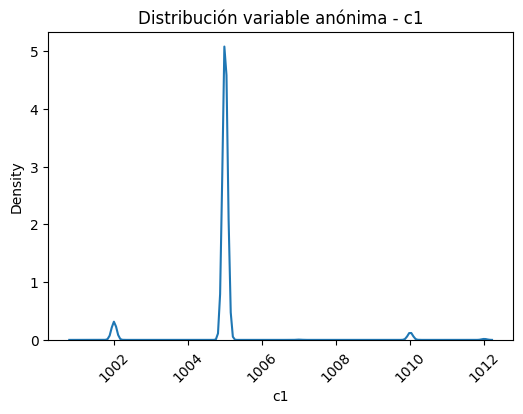

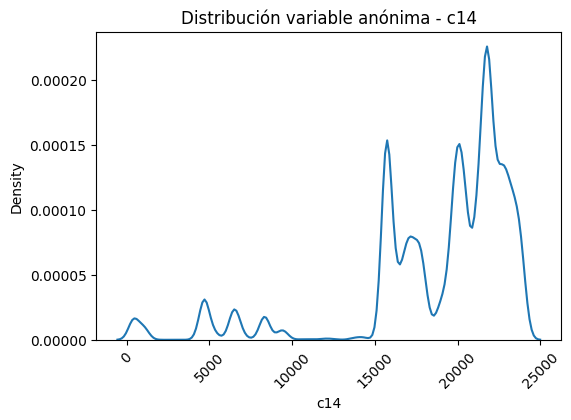

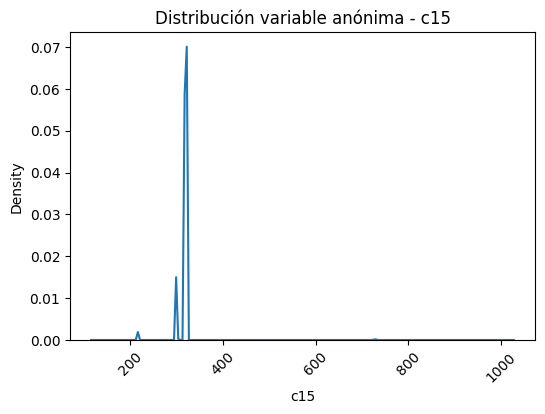

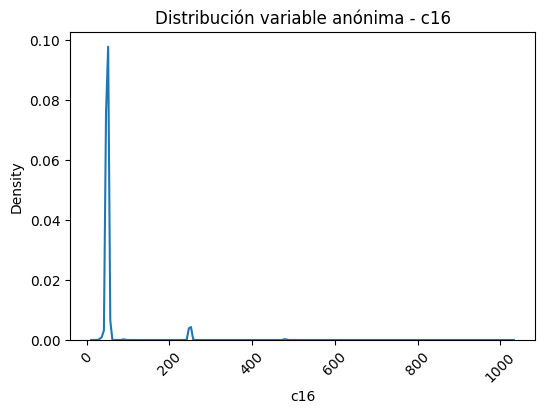

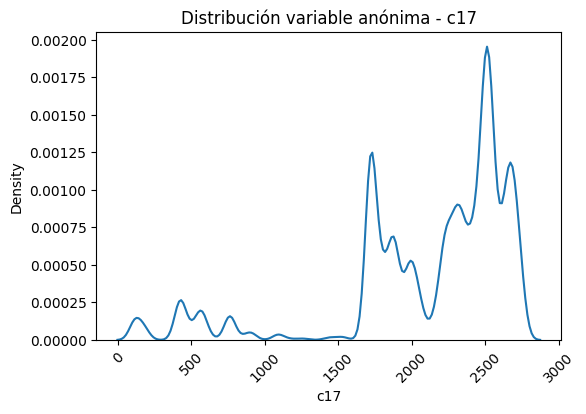

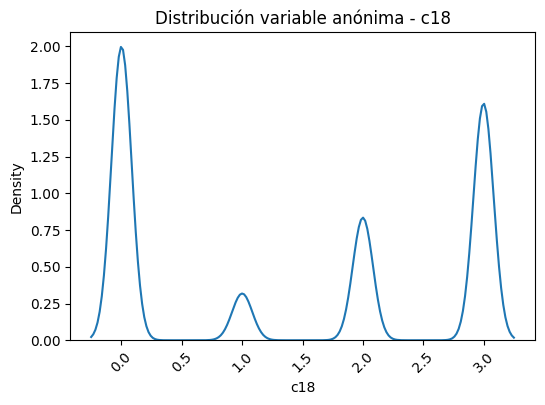

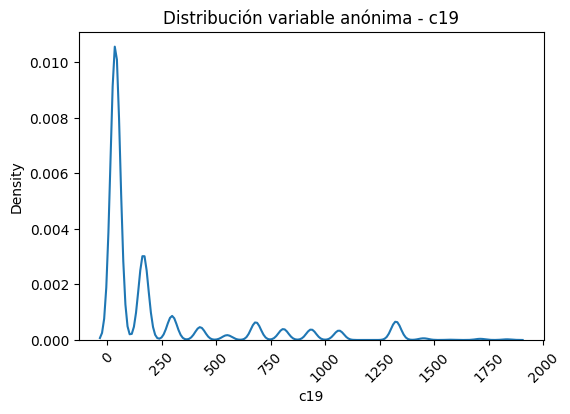

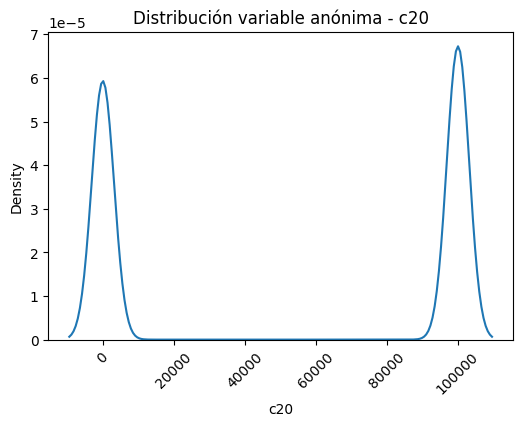

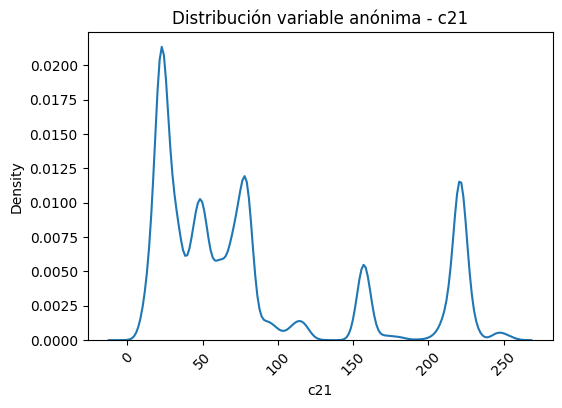

In [13]:
for var in variables_anon:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=var)
    
    plt.title(f'Distribución variable anónima - {var}')
    plt.xticks(rotation=45)
    plt.show()

En el caso de las variables `c1`, `c15`, `c16` y `c20`, observamos que la gran mayoría de las instancias se concentran en ciertos valores específicos. Esto sugiere, al menos para estas variables, un comportamiento típico de código o categorías predefinidas. 

Por otro lado, variables como `c14`, `c17`, `c19`, `c21` cuentan con rangos de valores más dispersos. Las variables `c14` y `c17`, parecen tener distribuciones similares.

La variable `c18`, cuenta con 4 valores únicos.

### **Proporción de cada categoría**

De forma complementaria, calculamos la proporción de cada categoría en las variables anónimas. Esto nos permite identificar qué tan distribuidas están las categorías y qué valores que concentran la mayor parte de las observaciones. Como parte del modelado en Scikit-Learn, agruparemos categorías con menos de un 1% de observaciones en la categoría `'OTHER'`.

In [14]:
for var in variables_anon:
    print(f"Proporción valores únicos en {var}", len(df[var].unique()))
    print(df[var].value_counts(normalize = True))

Proporción valores únicos en c1 7
c1
1005    0.918742
1002    0.054695
1010    0.022424
1012    0.002913
1007    0.000854
1001    0.000232
1008    0.000140
Name: proportion, dtype: float64
Proporción valores únicos en c14 2243
c14
4687     0.023452
21611    0.022674
21189    0.018759
21191    0.018611
19771    0.018165
           ...   
22486    0.000001
23515    0.000001
18591    0.000001
12008    0.000001
12210    0.000001
Name: proportion, Length: 2243, dtype: float64
Proporción valores únicos en c15 8
c15
320     0.932837
300     0.057519
216     0.007641
728     0.001771
1024    0.000080
120     0.000066
480     0.000049
768     0.000037
Name: proportion, dtype: float64
Proporción valores únicos en c16 9
c16
50      0.943276
250     0.044517
36      0.007641
480     0.002563
90      0.001771
768     0.000080
20      0.000066
320     0.000049
1024    0.000037
Name: proportion, dtype: float64
Proporción valores únicos en c17 422
c17
1722    0.111877
2424    0.037370
2227    0.036619

### **Matriz de correlación - Variables anónimas**

Para profundizar en el análisis de las variables anónimas, construimos una matriz de correlación que nos permita examinar las relaciones lineales entre ellas. Además de su relación con nuestra variable objetivo.

<Axes: >

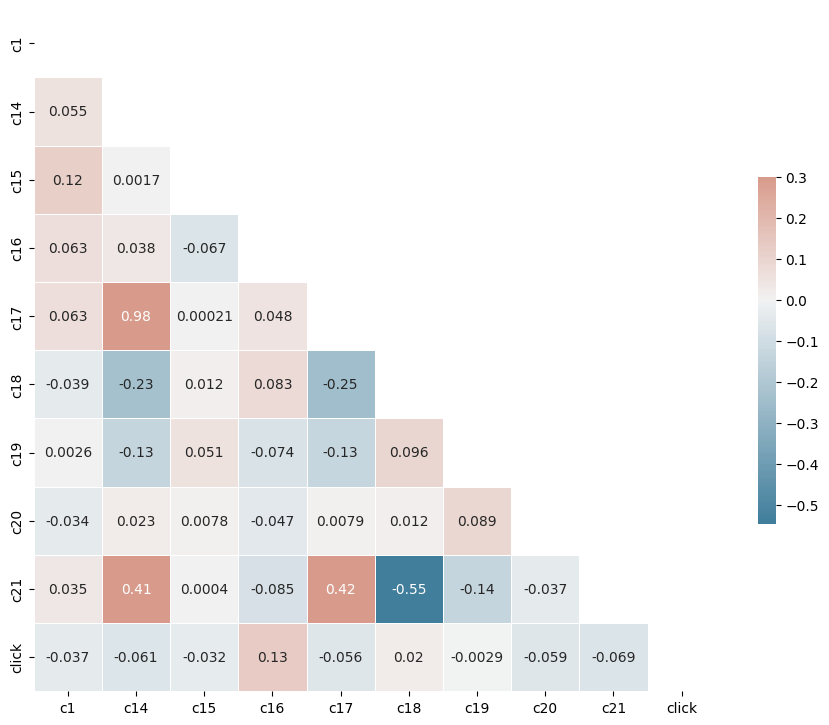

In [15]:
corr = df[variables_anon + ['click']].corr()


mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

Con relación a los valores observados en la matriz de correlación. En primer lugar, observamos una baja correlación entre las variables anónimas y la variable objetivo click, lo que confirma que estas variables se comportan más como identificadores o códigos.

Correlaciones valiosas entre variables:

* `c14 vs c17` | 0.98: Presentan una correlación muy alta de 0.98, redundancia entre ambas. 

* `c14 vs c21` | 0.41: Correlación moderada positiva

* `c17 vs c21` | 0.42: Mismo comportamiento observado en c14 vs c21

* `c18 vs c21` | -0.55: Destaca una correlación negativa moderada de -0.55, lo que señala una relación inversa

## **Distribución variables categóricas**

Procedemos a analizar la distribución de las variables categóricas presentes en el dataset, evaluando proprciones en valores únicos y concentraciones.

In [16]:
var_cat = ['device_model', 'site_domain', 'app_domain', 'app_category','site_category','banner_pos','device_type','device_conn_type']

In [ ]:
for var in var_cat:
    print(f"Proporción valores únicos en {var}", len(df[var].unique()))
    print(df[var].value_counts(normalize = True))

unique counts of site_category 5134
device_model
8a4875bd    0.060749
1f0bc64f    0.034992
d787e91b    0.034705
76dc4769    0.019032
be6db1d7    0.018531
              ...   
92f4ba26    0.000001
f105819b    0.000001
0a426b70    0.000001
0ad241a6    0.000001
ea7e24e9    0.000001
Name: proportion, Length: 5134, dtype: float64
unique counts of site_category 2856
site_domain
c4e18dd6    0.374018
f3845767    0.160469
7e091613    0.082353
7687a86e    0.031838
98572c79    0.024928
              ...   
4a7c84c3    0.000001
556161c2    0.000001
15232937    0.000001
655cfaeb    0.000001
1d61eb21    0.000001
Name: proportion, Length: 2856, dtype: float64
unique counts of site_category 201
app_domain
7801e8d9    0.674205
2347f47a    0.129211
ae637522    0.045997
5c5a694b    0.027740
82e27996    0.018876
              ...   
23e2c80e    0.000001
7ecafa37    0.000001
b6c7e8e1    0.000001
5ced45bd    0.000001
fd68cbd8    0.000001
Name: proportion, Length: 201, dtype: float64
unique counts of site_ca

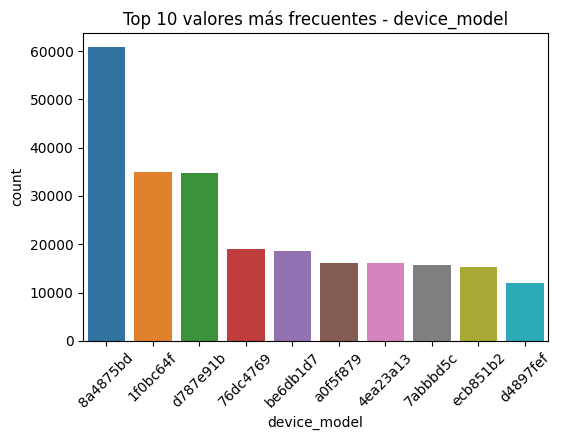

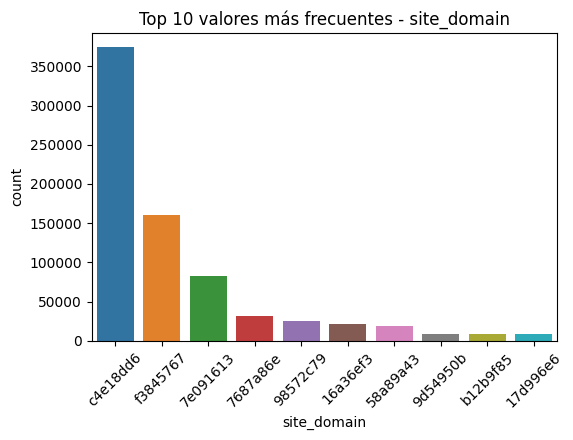

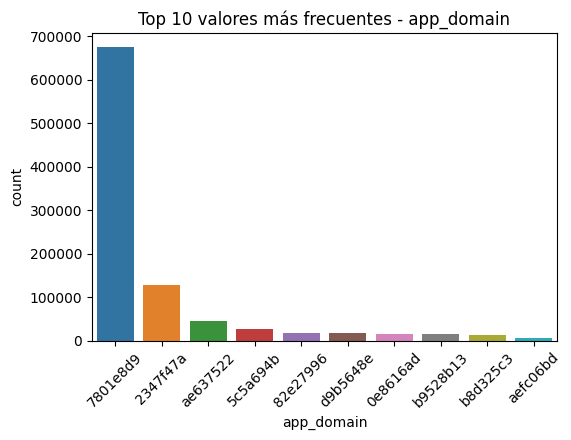

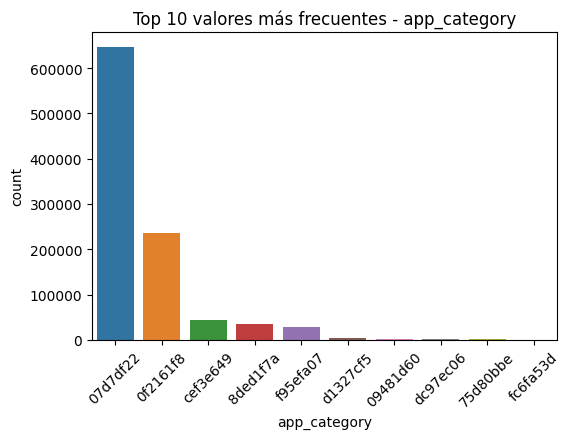

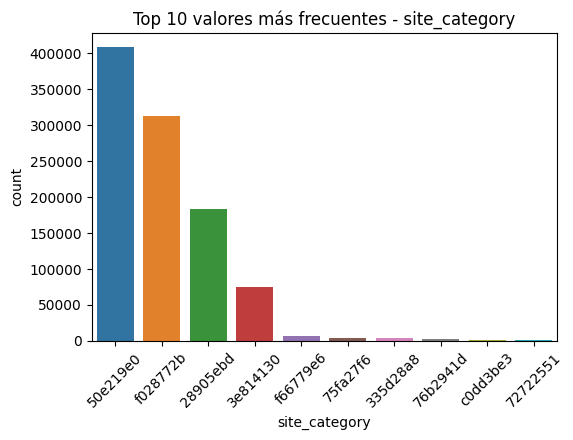

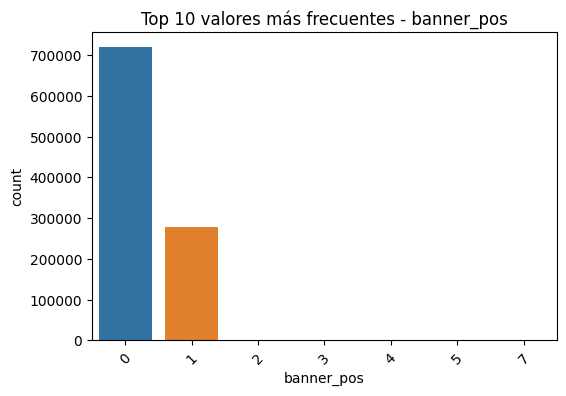

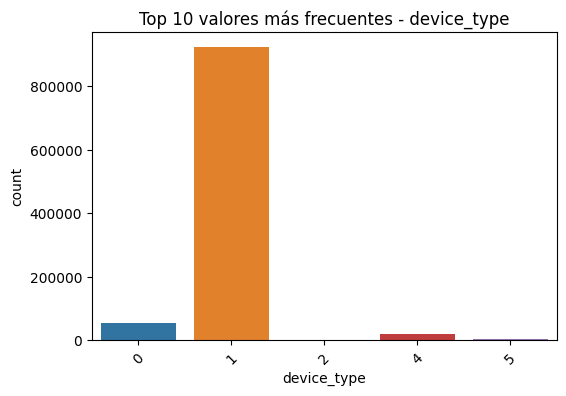

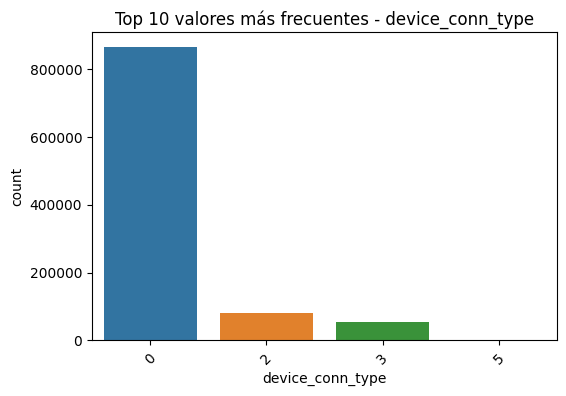

In [142]:
for var in var_cat:
    top10 = df[var].value_counts().head(10).reset_index()
    top10.columns = [var, 'count']

    plt.figure(figsize=(6,4))
    sns.barplot(data=top10, x=var, y='count')
    
    plt.title(f'Top 10 valores más frecuentes - {var}')
    plt.xticks(rotation=45)
    plt.show()

Al examinar la distribución de frecuencias para las variables con alta cardinalidad, podemos destacar los siguientes patrones:

* `device_model`: Observamos que los 10 modelos de dispositivo más frecuentes tienen volúmenes de aparición relativamente equilibrados entre sí. Ninguno de ellos concentra una proporción abrumadoramente mayoritaria de los registros, lo que sugiere una diversidad considerable.

* `site_domain`: Aquí se evidencia una concentración mucho más marcada. El dominio principal acumula alrededor de 370,000 registros, superando ampliamente al segundo (160,000) y al resto.

* `app_domain`: El dominio de aplicación más frecuente concentra aproximadamente 680,000 registros, lo que representa más de dos tercios del total del subsample.

* `app_category`: La categoría de aplicación más frecuente también muestra una alta concentración, con un comportamiento parecido a `app_domain`.

* `site_category`: Comportamiento parecido a `app_category`, 400,000 registros la categoría principal.

* `banner_pos`, `device_type`, `device_conn_type`: Pocos valores únicos, concentraciones altas entre 2-3 valores. 

## **Distribuciones variables temporales**

A continuación, procedemos a analizar el comportamiento de las variables temporales derivadas (hora, día, mes y año).

In [143]:
var_temporales = ['hour', 'dia', 'mes', 'año']

In [144]:
df[var_temporales].describe()

,hour,dia,mes,año
count,1000000.000000,1000000.000000,1000000.0,1000000.0
mean,11.274396,25.469938,10.0,2014.0
std,5.958183,2.963766,0.0,0.0
min,0.000000,21.000000,10.0,2014.0
25%,6.000000,23.000000,10.0,2014.0
50%,11.000000,26.000000,10.0,2014.0
75%,16.000000,28.000000,10.0,2014.0
max,23.000000,30.000000,10.0,2014.0


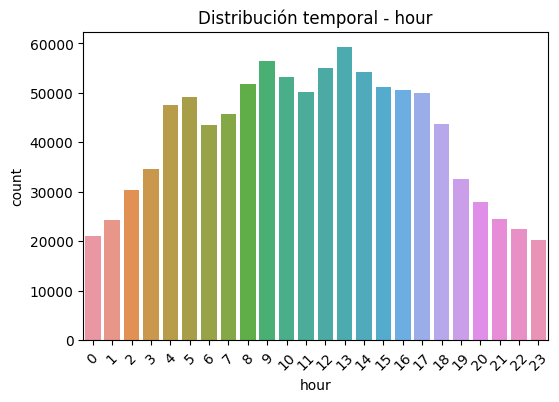

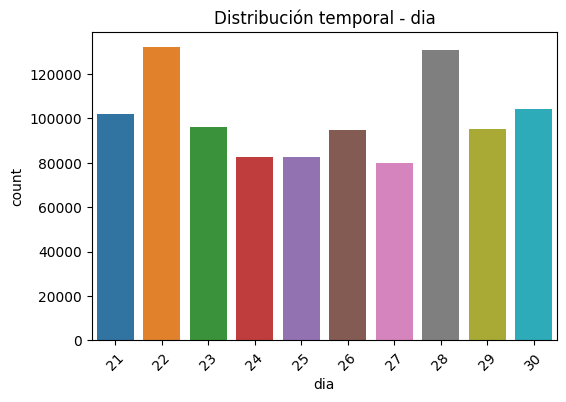

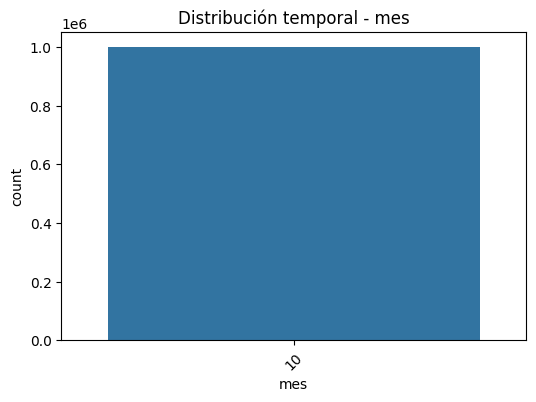

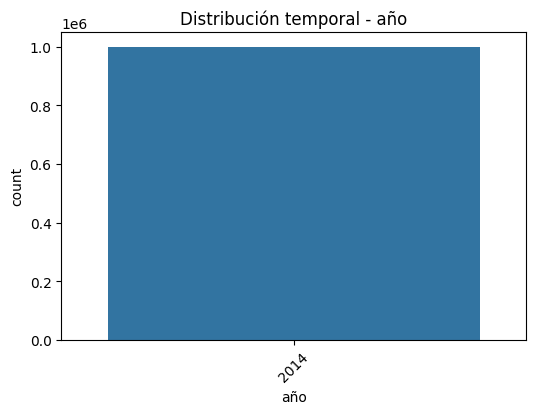

In [145]:
for var in var_temporales:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=var)
    
    plt.title(f'Distribución temporal - {var}')
    plt.xticks(rotation=45)
    plt.show()

* `hour`: La actividad por horas muestra un comportamiento esperado de usuarios activos durante el día. La mayor actividad de usuarios se presenta durante las 7 y las 17 horas, con picos que rondan los 60,000 registros en estas horas centrales. Por el contrario, las horas de madrugada (entre las 0 y las 6 horas) presentan la actividades más bajas, con valores que rondan los 20,000 registros

* `dia`: En los días analizados (del 21 al 30), observamos fluctuaciones significativas. Los días 22 y 28 concentran los volúmenes más altos, superando los 130,000 usuarios activos, mientras que el día 27 presenta el registro más bajo, cercano a 80,000. Estas variaciones podrían estar asociadas a días específicos de la semana.

* `mes`, `año`: Las gráficas de mes y año no aportan información relevante, dado que el dataset contempla únicamente registros del mes de Noviembre en el año 2014.

Para el modelado final excluiremos las variables `año`, `mes`, `dia` , dado que cuentan con pocas categorías que no añaden valor predictivo al modelo.

## **Distribución variable Objetivo**

Procedemos a observar la distribución de nuestra variable objetivo.

In [146]:
df['click'].value_counts(normalize = True)

click
0    0.830263
1    0.169737
Name: proportion, dtype: float64

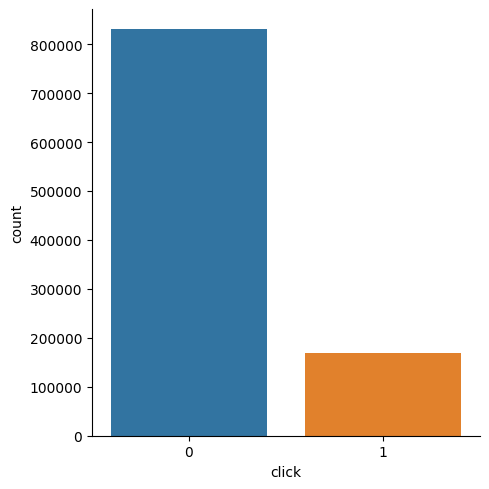

In [147]:
sns.catplot(data=df, x='click', kind='count')

Observamos un alto desbalance de clases, favoreciendo la clase de `'no click'` con 83% de los registros, `'click'` 17% de los registros.

## **Análisis Bivariado**

### **Distribución click con respecto a hora**

Estudiamos la relación de entre `click` y hora del día.

<Figure size 600x400 with 0 Axes>

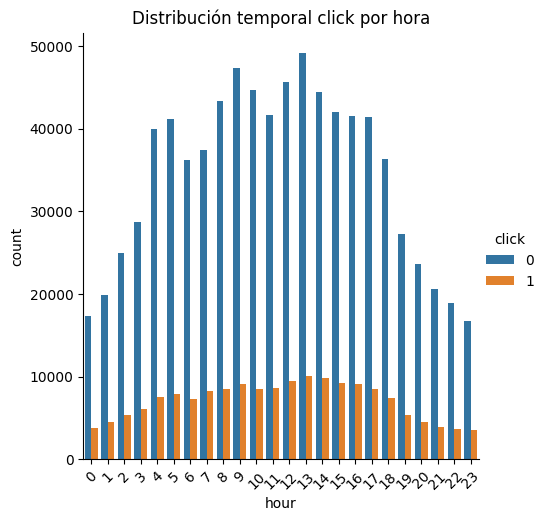

In [148]:
plt.figure(figsize=(6,4))
sns.catplot(data=df, x='hour', kind='count', hue='click')

plt.title(f'Distribución temporal click por hora')
plt.xticks(rotation=45)
plt.show()

### **Tasa de clicks por hora**

In [149]:
ctr_hour = df.groupby('hour')['click'].mean() * 100
print(ctr_hour)

hour
0     17.697228
1     18.605988
2     17.476081
3     17.383662
4     15.837628
5     16.172276
6     16.691234
7     18.002234
8     16.415808
9     16.113543
10    16.011130
11    17.046924
12    17.117902
13    17.067494
14    18.133265
15    17.974437
16    18.081013
17    17.088608
18    16.837294
19    16.294018
20    15.944096
21    16.007025
22    16.122594
23    17.435999
Name: click, dtype: float64


Las horas de 0 a 3 am cuentan tasas de clicks altas (`17-18%`). Lo que podría indicar que los usuarios que navegan de madrugada son más propensos a hacer clic, se observa un segundo pico a las 7 horas (`18%`), este grupo pertenece al de personas que revisan sus dispositivos al despertar. Por último, se observa un tercer pico de las 2 a 5 pm (`17-18%`), estas horas están asociadas comunmente con horas de descanso laboral.

Las dos horas que cuentan con menor tasa de clicks corresponden a las 4 am y 8 pm (`15%`). Este comportamiento podría estar asociado a desconexión nocturna y relacionado con horarios de cena (8 pm)

### **Relación variable click, con variables anónimas**

Evaluamos el comportamiento de clicks con relación a la distribución de variables anónimas

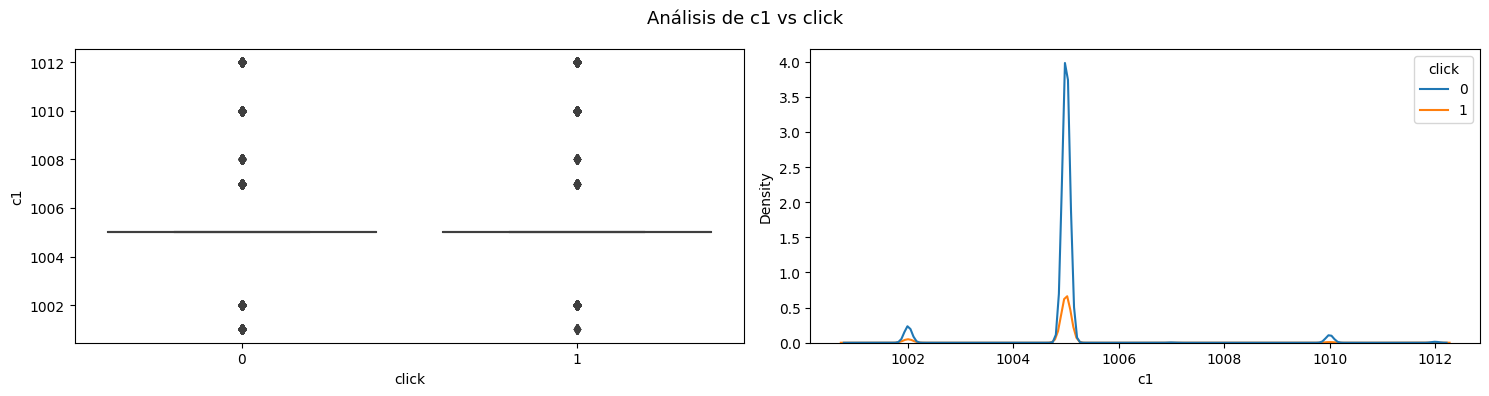

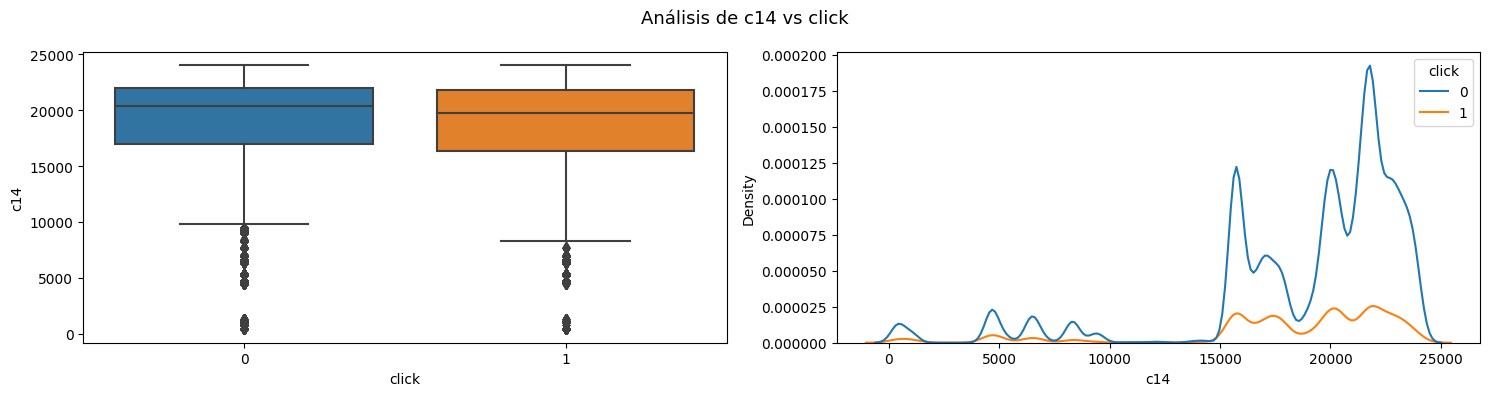

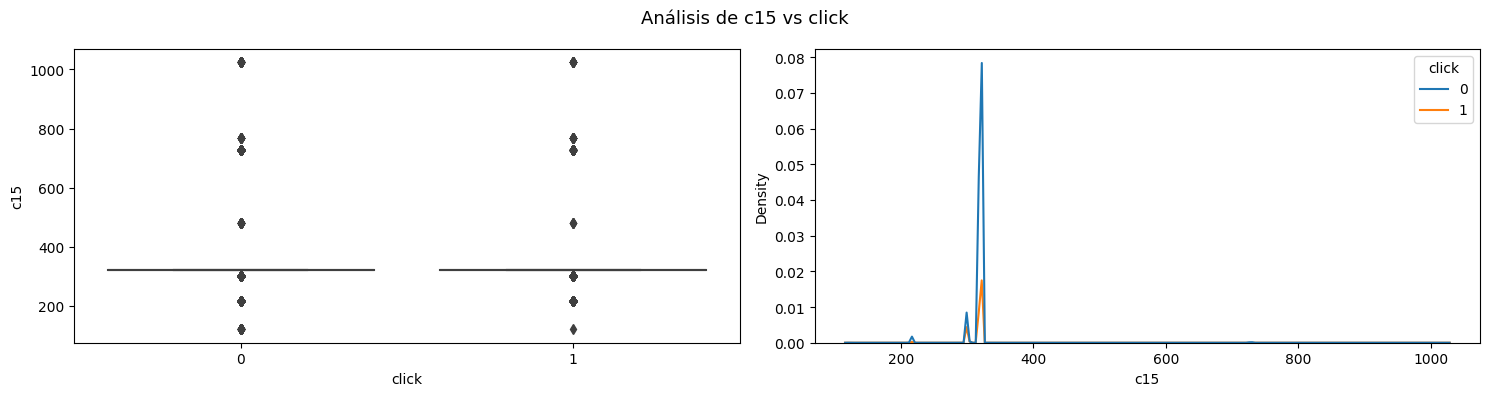

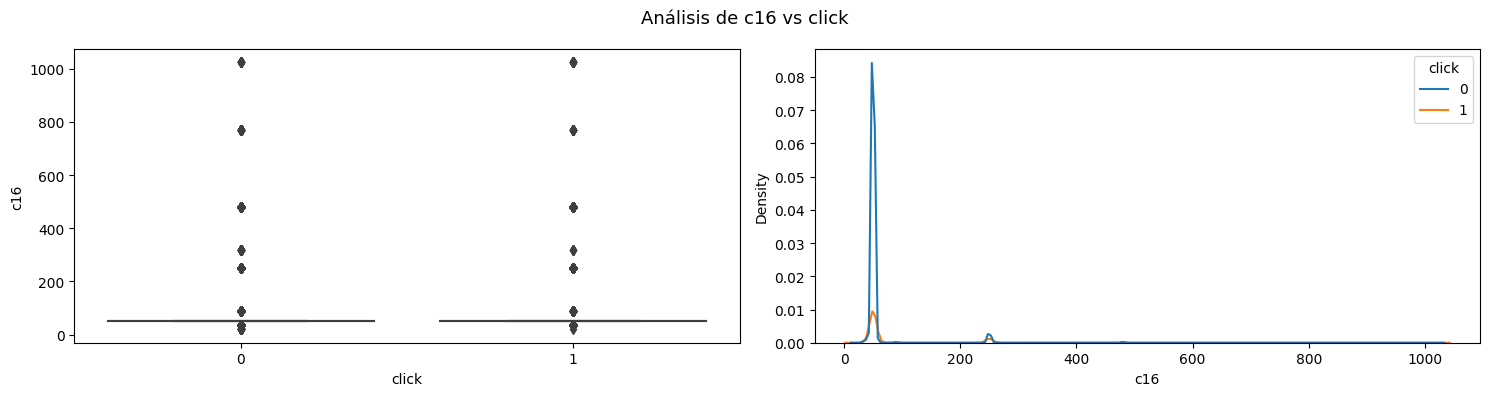

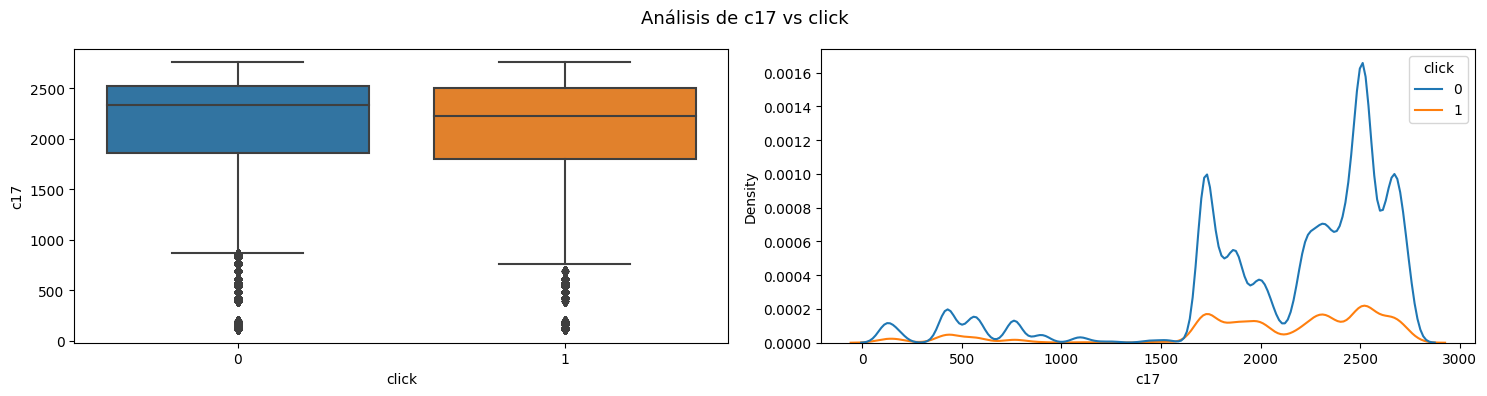

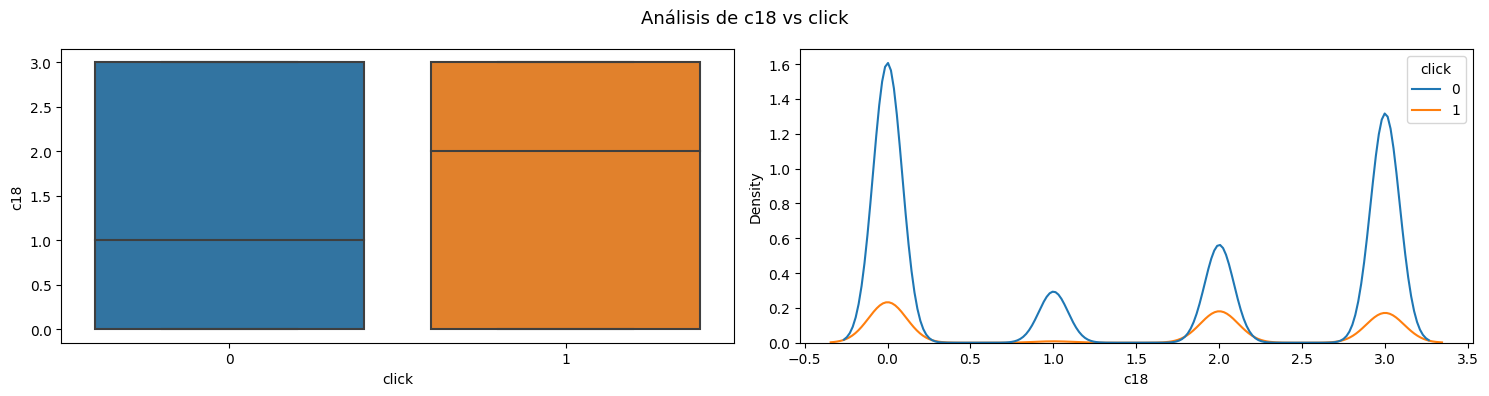

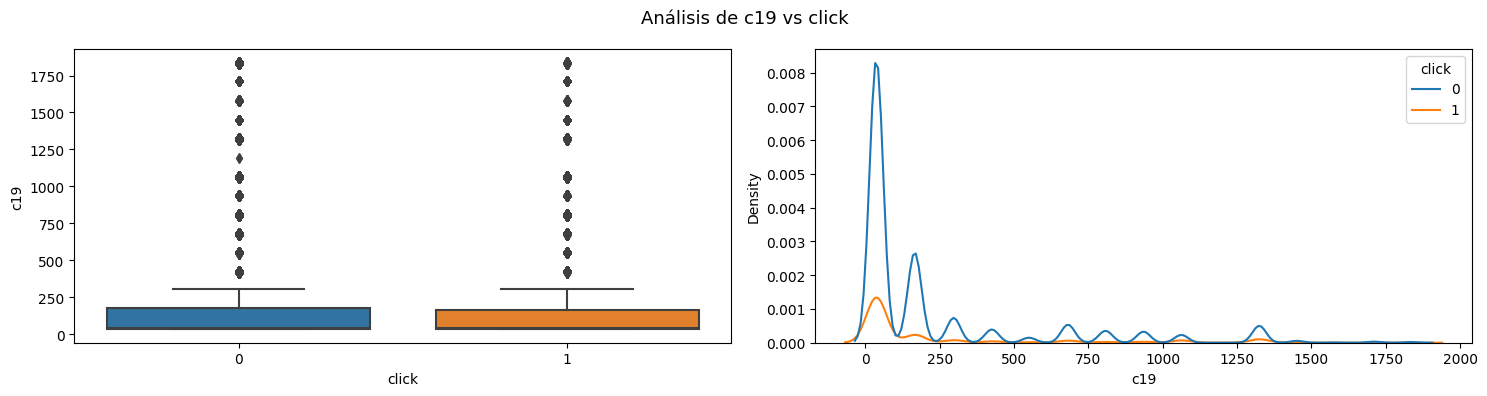

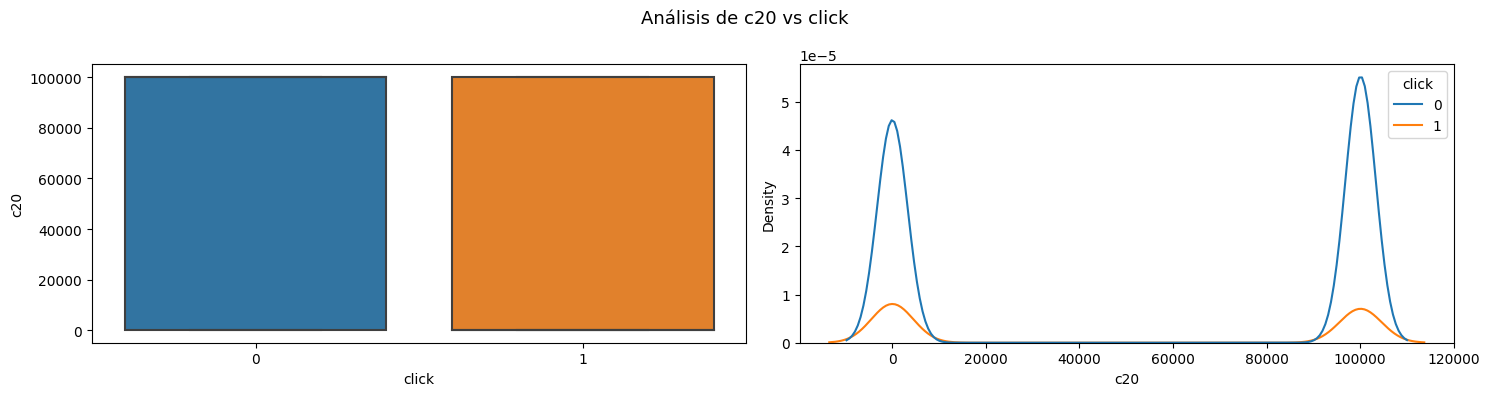

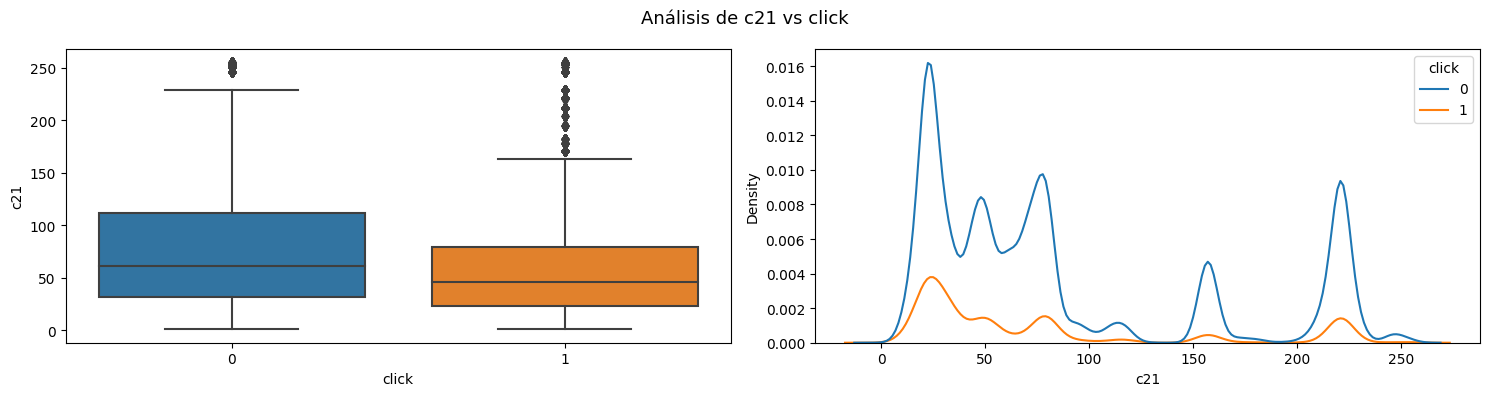

In [150]:
for var in variables_anon:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f'Análisis de {var} vs click', fontsize=13)
    
    sns.boxplot(data=df, x='click', y=var, ax=axes[0])
    sns.kdeplot(data=df, x=var, hue='click', ax=axes[1])
    
    plt.tight_layout()
    plt.show()

La distribución de la variables anónimas es similar para las observaciones con y sin click. Los picos de densidad se presentan en los mismos valores para ambas clases, lo que sugiere que la presencia de clicks sigue principalmente la distribución general de las impresiones. Este hallazgo sugiere que, de manera individual, estas variables no discriminan claramente entre las clases y su aporte al modelo podría manifestarse a través de interacciones con otras variables, captando relaciones no lineales.

### **Relación variables categóricas con variable click**

Relación entre variables categóricas no anónimas y variable click.

<Figure size 600x400 with 0 Axes>

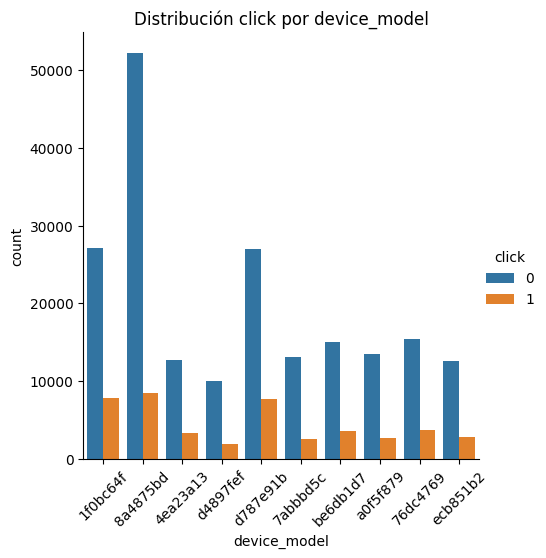

<Figure size 600x400 with 0 Axes>

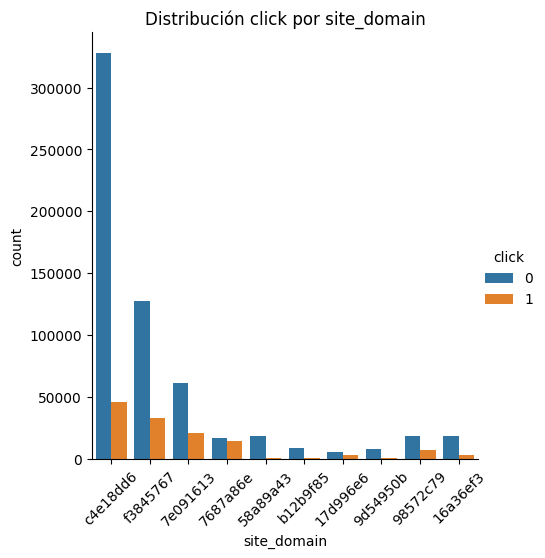

<Figure size 600x400 with 0 Axes>

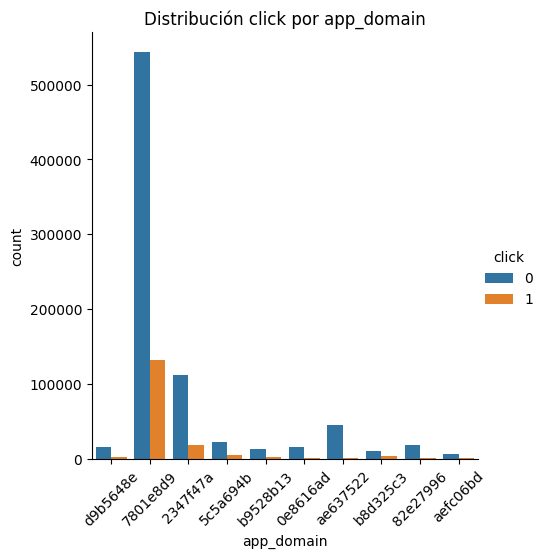

<Figure size 600x400 with 0 Axes>

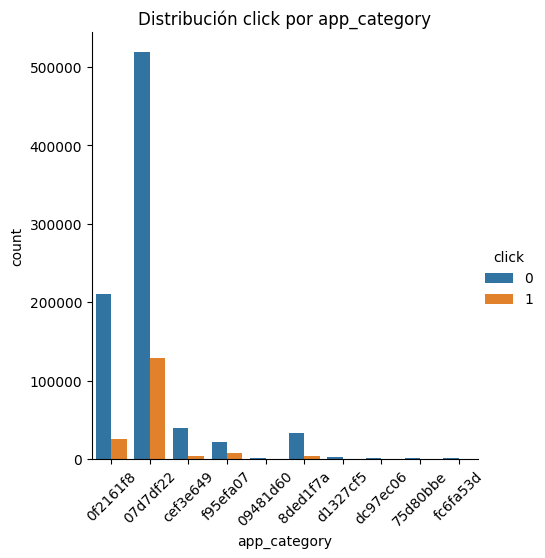

<Figure size 600x400 with 0 Axes>

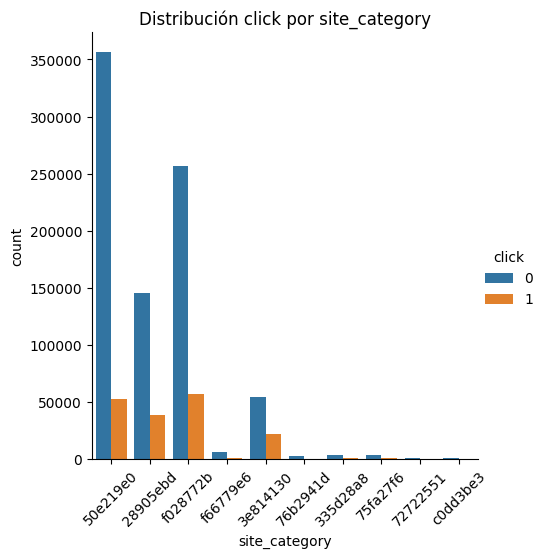

<Figure size 600x400 with 0 Axes>

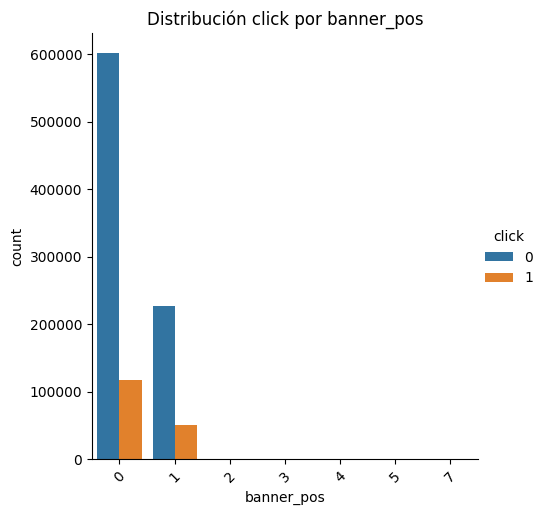

<Figure size 600x400 with 0 Axes>

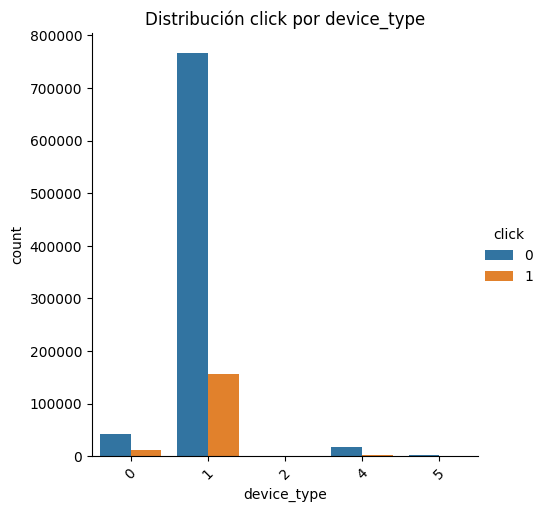

<Figure size 600x400 with 0 Axes>

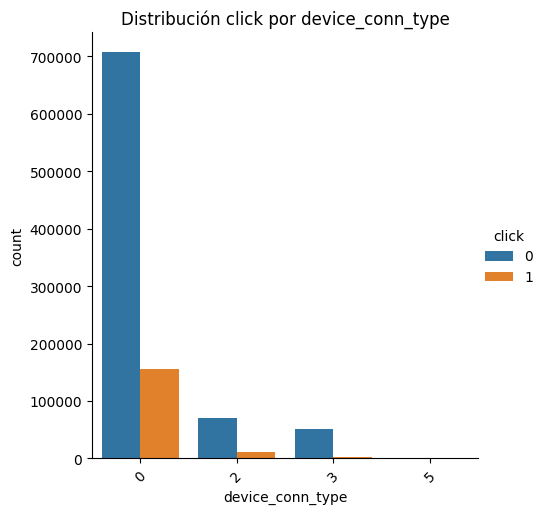

In [151]:
for var in var_cat:
    top10 = df[var].value_counts().head(10).index
    subset = df[df[var].isin(top10)]
    
    plt.figure(figsize=(6,4))
    sns.catplot(data=subset, x=var, kind='count', hue='click')

    plt.title(f'Distribución click por {var}' )
    plt.xticks(rotation=45)
    plt.show()

Caso similar a las variables anónimas. Al analizar los conteos absolutos, no se observan diferencias claras entre las clases que permitan identificar categorías específicas con una mayor propensión al click.

### **Guardado del Dataframe para uso en Sklearn**

In [152]:
df.to_csv(os.path.join(os.getcwd(), r'datos\train\train_sklearn_model.csv'), index=False)

## **Conclusiones**

* **Variables identificadoras**: Se eliminaron aquellas columnas que funcionaban como identificadores únicos (`id`, `device_ip`, `device_id`, `app_id`, `site_id`), ya que no aportaban valor predictivo y podían generar ruido en el modelo.

* **Variables temporales**: La variable `hour` mostró un patrón claro de estacionalidad diurna, con tasas de clics más altas en horarios específicos (madrugada, mañana temprano y tarde). En cambio, `dia`, `mes` y `año` serán excluidas dado que el período analizado no permite extraer patrones útiles a partir de ellas.


* **Variables anónimas y categóricas**: La mayoría presentan distribuciones son similares entre clicks y no clicks, lo que sugiere que la contribución de estas variables al modelo podría manifestarse principalmente a través de interacciones no linales. Además, eliminaremos la variable `c14`, ya que presenta una alta correlación con la variable `c17`. Este nivel de correlación indica que ambas variables contienen información redundante y por lo tanto, describen patrones muy similares dentro del conjunto de datos.

### **Modelado**
Procederemos a la etapa de modelado utilizando dos enfoques complementarios:

En **Scikit-learn**:

* Aplicaremos `Target Encoding` para codificar las variables categóricas, reemplazando cada categoría por la tasa de clicks promedio correspondiente.

* Para evitar estimaciones extremadamente bajas o altas en aquellas categorías con pocas observaciones, agruparemos las categorías raras (aquellas con frecuencia baja) antes de la codificación.

En **PySpark**:

* Para controlar la dimensionalidad, en las variables con alta cardinalidad se convervaremos únicamente las 50 categorías más frecuentes, agrupando el resto bajo la etiqueta `'OTHER'`.

* Se aplicará undersampling para reducir el dataset de 40M a 10M de registros balanceados (50% click / 50% no click).

* Aplicaremos `One Hot Encoding` para codificar las variables categóricas.
